In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
# from sklearn.datasets import load_boston
from torch import nn
from tqdm.notebook import tqdm
from IPython.display import clear_output

%matplotlib inline

In [2]:
print(torch.backends.mps.is_available())        # True — значит можно использовать
print(torch.backends.mps.is_built())            # True — значит PyTorch собран с поддержкой

True
True


In [27]:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [3]:
mnist_train = torchvision.datasets.MNIST(
    "./mnist/", 
    train=True, 
    download=True, 
    transform=torchvision.transforms.ToTensor()
) 
mnist_val = torchvision.datasets.MNIST(
    "./mnist/",
    train=False, 
    download=True,
    transform=torchvision.transforms.ToTensor()
)

train_dataloader = torch.utils.data.DataLoader(
    mnist_train, 
    batch_size=4, 
    shuffle=True, 
    num_workers=1
) 

val_dataloader = torch.utils.data.DataLoader(
    mnist_val, 
    batch_size=4, 
    shuffle=True, 
    num_workers=1
)

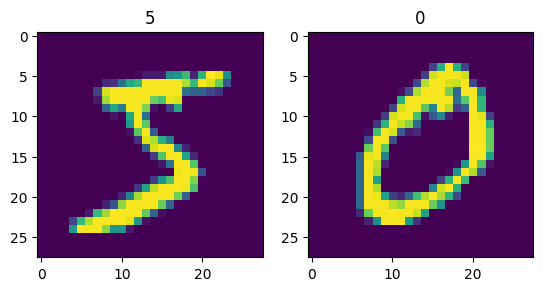

In [4]:
for i in [0, 1]:
    plt.subplot(1, 2, i + 1)
    plt.imshow(mnist_train[i][0].squeeze(0).numpy().reshape([28, 28]))
    plt.title(str(mnist_train[i][1]))
plt.show()

In [5]:
model = nn.Sequential(
    nn.Flatten(),             # превращаем картинку 28х28 в вектор размером 784
    nn.Linear(28 * 28, 128),  # линейный слой, преобразующий вектор размера 784 в вектор размера 128
    nn.ReLU(),                # нелинейность
    nn.Linear(128, 10),       # линейный слой, преобразующий вектор размера 128 в вектор размера 10
    # nn.Softmax(dim=-1)        # софтмакс для получения вероятностного распределения над метками класса
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.05) 
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

In [40]:
for x_train, y_train in tqdm(train_dataloader):
    break
x_train.shape

  0%|          | 0/15000 [00:00<?, ?it/s]

torch.Size([4, 1, 28, 28])

In [42]:
for epoch in range(15):
    for x_train, y_train in tqdm(train_dataloader):  
        y_pred = model(x_train)                       
        loss = F.cross_entropy(y_pred, y_train)      
        loss.backward()                               
        optimizer.step()                        
        optimizer.zero_grad()         
    
    if epoch % 2 == 0:
        val_loss = []                         
        val_accuracy = []
        with torch.no_grad():                  
            for x_val, y_val in tqdm(val_dataloader): 
                y_pred = model(x_val)                
                loss = F.cross_entropy(y_pred, y_val)  
                val_loss.append(loss.numpy())      
                val_accuracy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())
          
        print(f"Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}")

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Epoch: 0, loss: 0.0923798680305481, accuracy: 0.973


  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

...

Epoch: 12, loss: 0.08054862916469574, accuracy: 0.9823


  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Epoch: 14, loss: 0.0822008028626442, accuracy: 0.9826


In [6]:
torch.save(model.state_dict(), "model_weights.pth")

model.load_state_dict(torch.load("model_weights.pth"))
model.eval()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)

# adversarial attacks

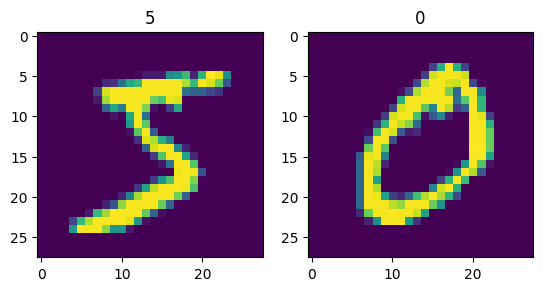

In [8]:
for i in [0, 1]:
    plt.subplot(1, 2, i + 1)
    plt.imshow(mnist_train[i][0].squeeze(0).numpy())
    plt.title(str(mnist_train[i][1]))
plt.show()

In [9]:
mnist_train[0][0].unsqueeze(0).shape

torch.Size([1, 1, 28, 28])

In [10]:
print("model predict:", model(mnist_train[0][0].unsqueeze(0)).argmax(dim=1))
print("target:", mnist_train[0][-1])

model predict: tensor([9])
target: 5


# cross_entropy

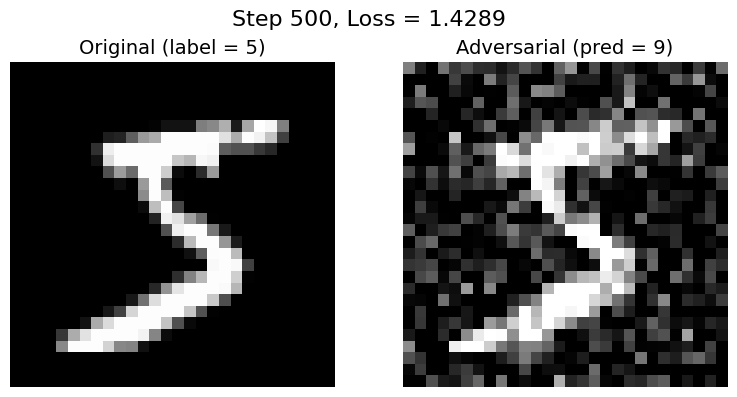

In [34]:
model.eval() 

x, original_label = mnist_train[0][0].unsqueeze(0), mnist_train[0][1]
x_adv = x.clone().detach().requires_grad_(True)
target_label = torch.tensor([9])

optimizer = torch.optim.SGD([x_adv], lr=0.1)  

for i in range(500):
    optimizer.zero_grad()
    output = model(x_adv)
    loss = F.cross_entropy(output, target_label)
    loss.backward()
    optimizer.step()
    
    # Ограничение значений пикселей
    with torch.no_grad():
        x_adv.data = torch.clamp(x_adv.data, min=0, max=1)
    
    pred = output.argmax(dim=1).item()
    

    if (i + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Original (label = {original_label})", fontsize=14)
        plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.title(f"Adversarial (pred = {pred})", fontsize=14)
        plt.imshow(x_adv.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.suptitle(f"Step {i+1}, Loss = {loss.item():.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

Атака срабатывает уже на 5 шаге. При большом количестве шагов похоже больше на шум.
* Попробуем сменить лосс.

# MSE 

In [32]:
# Возьмём целевое значение
mnist_train[4][1]

9

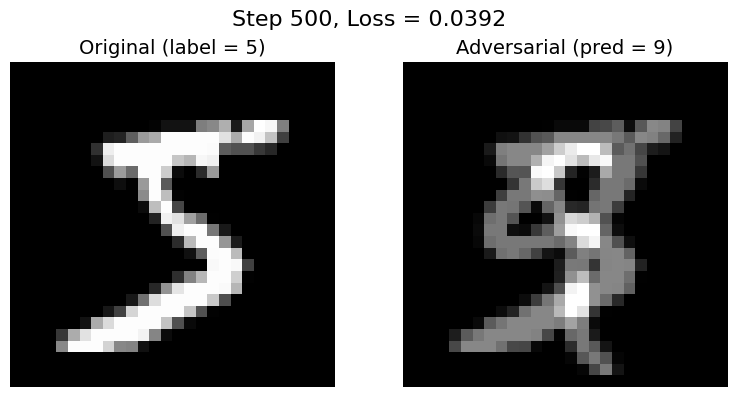

In [46]:
model.eval() 


x, original_label = mnist_train[0][0].unsqueeze(0), mnist_train[0][1]
x_adv = x.clone().detach().requires_grad_(True)
# target_label = torch.tensor([9])

optimizer = torch.optim.SGD([x_adv], lr=0.5)  
target_x = mnist_train[4][0].unsqueeze(0)

for i in range(500):
    optimizer.zero_grad()
    output = model(x_adv)
    # loss = F.cross_entropy(output, target_label)
    loss = F.mse_loss(x_adv, target_x)
    loss.backward()
    optimizer.step()
    
    # Ограничение значений пикселей
    with torch.no_grad():
        x_adv.data = torch.clamp(x_adv.data, min=0, max=1)
    
    pred = output.argmax(dim=1).item()
    

    if (i + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Original (label = {original_label})", fontsize=14)
        plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.title(f"Adversarial (pred = {pred})", fontsize=14)
        plt.imshow(x_adv.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.suptitle(f"Step {i+1}, Loss = {loss.item():.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

Модель весьма бысто создаёт адверсариал атаку. Замена происходит. Попробуем скомбинировать два лосса

# MSE + cross_entropy

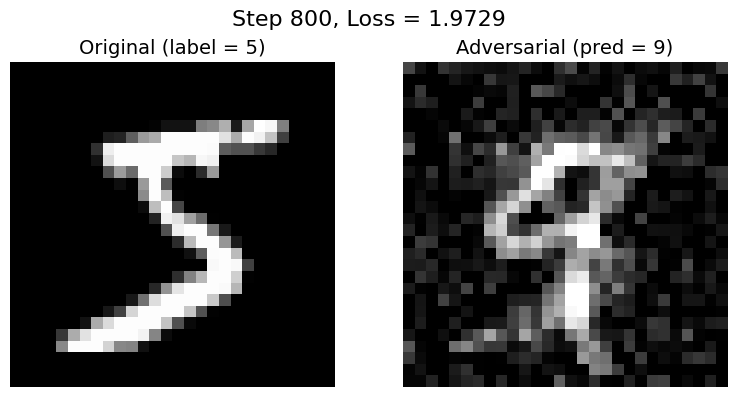

In [64]:
model.eval() 

x, original_label = mnist_train[0][0].unsqueeze(0), mnist_train[0][1]
x_adv = x.clone().detach().requires_grad_(True)
target_label = torch.tensor([9])

optimizer = torch.optim.SGD([x_adv], lr=0.05)  
target_x = mnist_train[4][0].unsqueeze(0)

for i in range(800):
    optimizer.zero_grad()
    output = model(x_adv)

    classification_loss = F.cross_entropy(output, target_label)
    similarity_loss = F.mse_loss(x_adv, target_x)
    loss = classification_loss + 10 * similarity_loss
    
    loss.backward()
    optimizer.step()
    
    # Ограничение значений пикселей
    with torch.no_grad():
        x_adv.data = torch.clamp(x_adv.data, min=0, max=1)
    
    pred = output.argmax(dim=1).item()
    

    if (i + 1) % 5 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(8, 4))
        
        plt.subplot(1, 2, 1)
        plt.title(f"Original (label = {original_label})", fontsize=14)
        plt.imshow(x.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.title(f"Adversarial (pred = {pred})", fontsize=14)
        plt.imshow(x_adv.squeeze().detach().numpy(), cmap="gray")
        plt.axis("off")
        
        plt.suptitle(f"Step {i+1}, Loss = {loss.item():.4f}", fontsize=16)
        plt.tight_layout()
        plt.show()

# Projected Gradient Descent

In [67]:
epsilon = 0.3
alpha = 0.01  
num_iter = 100

x_adv = x.clone().detach().requires_grad_(True)

for i in range(num_iter):
    output = model(x_adv)
    loss = F.cross_entropy(output, target_label)
    loss.backward()
    
    with torch.no_grad():
        x_adv.data = x_adv - alpha * x_adv.grad.sign()
        perturbation = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
        x_adv.data = torch.clamp(x + perturbation, min=0, max=1)
    
    x_adv.requires_grad_(True)
    
    pred = output.argmax(dim=1).item()
    
    if (i + 1) % 5 == 0:
        print(f"Step {i+1}, Loss = {loss.item():.4f}, Pred = {pred}")
        if pred == target_label.item():
            print("Атака успешна!")
            break

Step 5, Loss = 2.0410, Pred = 9
Атака успешна!


# DeepDream

# Styel Transfer

Используется устройство: mps
🔁 Style transfer начался...
Шаг 0, Style Loss: 0.0001, Content Loss: 0.0000
Шаг 50, Style Loss: 0.0000, Content Loss: 0.0000
Шаг 100, Style Loss: 0.0000, Content Loss: 0.0000
Шаг 150, Style Loss: 0.0000, Content Loss: 0.0000
Шаг 200, Style Loss: 0.0000, Content Loss: 0.0000
Шаг 250, Style Loss: 0.0000, Content Loss: 0.0000


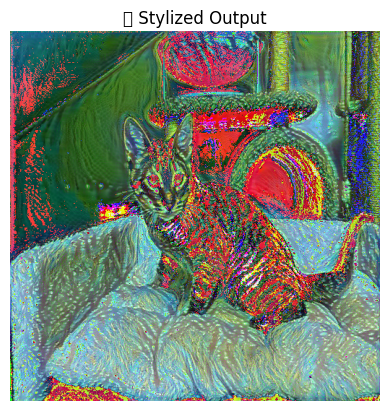

In [132]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy

# --- Устройство: mps (GPU Apple Silicon) или cpu ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используется устройство: {device}")

# --- Преобразование изображений ---
loader = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

def image_loader(path):
    image = Image.open(path).convert('RGB')
    image = loader(image).unsqueeze(0)  # добавляем batch размер
    return image.to(device, torch.float)

# --- Обратное преобразование ---
def imshow(tensor, title=None):
    unloader = transforms.ToPILImage()
    image = tensor.cpu().clone().squeeze(0)
    image = unloader(image)
    if title:
        plt.title(title)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# --- Грам-матрица ---
def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(b, c, h * w)
    G = torch.bmm(features, features.transpose(1, 2))
    return G / (c * h * w)

# --- Content Loss ---
class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

# --- Style Loss ---
class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

# --- Подготовка модели VGG + Loss'ы ---
def get_style_model_and_losses(cnn, style_img, content_img,
                                content_layer='conv4_2',
                                style_layers=['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']):

    cnn = copy.deepcopy(cnn)
    content_losses = []
    style_losses = []
    model = nn.Sequential()

    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = f'conv{i}_1'
        elif isinstance(layer, nn.ReLU):
            name = f'relu{i}_1'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool{i}_1'
            layer = nn.AvgPool2d(kernel_size=2, stride=2)
        else:
            continue

        model.add_module(name, layer)

        if name == content_layer:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{name}", content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            target = model(style_img).detach()
            style_loss = StyleLoss(target)
            model.add_module(f"style_loss_{name}", style_loss)
            style_losses.append(style_loss)

        if len(style_losses) == len(style_layers) and content_losses:
            break

    return model, style_losses, content_losses

# --- Главная функция style transfer ---
def run_style_transfer(cnn, content_img, style_img, input_img, num_steps=300,
                       style_weight=1e6, content_weight=1.0):
    model, style_losses, content_losses = get_style_model_and_losses(cnn, style_img, content_img)
    optimizer = optim.Adam([input_img.requires_grad_()], lr=0.02)

    print("🔁 Style transfer начался...")
    for step in range(num_steps):
        optimizer.zero_grad()
        model(input_img)
    
        style_score = sum((sl.loss for sl in style_losses), torch.tensor(0.0, device=device))
        content_score = sum((cl.loss for cl in content_losses), torch.tensor(0.0, device=device))
    
        loss = style_weight * style_score + content_weight * content_score
        loss.backward()
        optimizer.step()
    
        if step % 50 == 0:
            print(f"Шаг {step}, Style Loss: {style_score.item():.4f}, Content Loss: {content_score.item():.4f}")


    return input_img

# --- Загрузка изображений ---
content_path = "cat.jpg"
style_path = "vangog4.jpg"

content_img = image_loader(content_path)
style_img = image_loader(style_path)
input_img = content_img.clone().to(device)

# --- Запуск ---
cnn = models.vgg19(pretrained=True).features.to(device).eval()
output = run_style_transfer(cnn, content_img, style_img, input_img)

# --- Сохранение результата ---
output_img = output.cpu().clone().squeeze(0)
output_img = transforms.ToPILImage()(output_img)
output_img.save("output.jpg")
imshow(output, title="🎨 Stylized Output")

BasicConv2d(
  (conv): Conv2d(2048, 320, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn): BatchNorm2d(320, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
)

# fix 1

Используется устройство: mps
🔁 Style transfer начался...
Шаг 0, Style Loss: 0.0002, Content Loss: 0.0000
Шаг 50, Style Loss: 0.0000, Content Loss: 2.5650
Шаг 100, Style Loss: 0.0000, Content Loss: 1.7743
Шаг 150, Style Loss: 0.0000, Content Loss: 1.5407
Шаг 200, Style Loss: 0.0000, Content Loss: 1.4152
Шаг 250, Style Loss: 0.0000, Content Loss: 1.3335


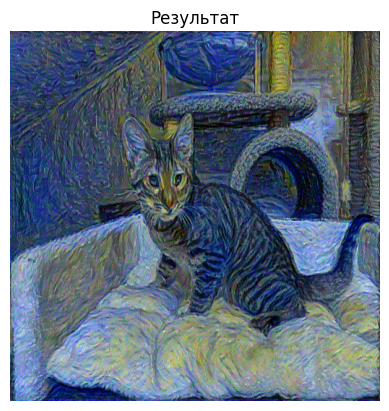

In [157]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используется устройство: {device}")

# Добавляем нормализацию для VGG
loader = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def image_loader(path):
    image = Image.open(path).convert('RGB')
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

# Функция денормализации для отображения
def imshow(tensor, title=None):
    unloader = transforms.ToPILImage()
    image = tensor.cpu().clone().squeeze(0)
    image = unloader(image)
    if title:
        plt.title(title)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(b, c, h * w)
    G = torch.bmm(features, features.transpose(1, 2))
    return G.div(c * h * w)

class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

def get_style_model_and_losses(cnn, style_img, content_img):
    content_layers = ['conv_21']  # conv4_2
    style_layers = ['conv_0', 'conv_5', 'conv_10', 'conv_19', 'conv_28']  # conv1_1, conv2_1 и т.д.
    
    cnn = copy.deepcopy(cnn)
    content_losses = []
    style_losses = []
    model = nn.Sequential()
    
    i = 0
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
            layer = nn.AvgPool2d(kernel_size=2, stride=2)
        else:
            continue
        
        model.add_module(name, layer)
        
        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)
        
        if name in style_layers:
            target = model(style_img).detach()
            style_loss = StyleLoss(target)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)
        
        i += 1
    
    return model, style_losses, content_losses

def run_style_transfer(cnn, content_img, style_img, input_img, num_steps=300,
                       style_weight=1e6, content_weight=1):
    model, style_losses, content_losses = get_style_model_and_losses(cnn, style_img, content_img)
    optimizer = optim.Adam([input_img.requires_grad_()], lr=0.5)

    print("🔁 Style transfer начался...")
    for step in range(num_steps):
        optimizer.zero_grad()
        model(input_img)
        
        style_loss = sum([sl.loss for sl in style_losses])
        content_loss = sum([cl.loss for cl in content_losses])
        
        total_loss = style_weight * style_loss + content_weight * content_loss
        total_loss.backward()
        optimizer.step()
        
        if step % 50 == 0:
            print(f"Шаг {step}, Style Loss: {style_loss.item():.4f}, Content Loss: {content_loss.item():.4f}")

    return input_img

# Загрузка с нормализацией
content_img = image_loader("cat.jpg")
style_img = image_loader("style.jpg")
input_img = content_img.clone()

# Запуск
cnn = models.vgg19(pretrained=True).features.to(device).eval()
output = run_style_transfer(cnn, content_img, style_img, input_img)

# Денормализация для отображения
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1).to(device)
    return tensor * std + mean

output = denormalize(output.squeeze(0)).clamp(0, 1)
imshow(output, title="Результат")

Используется устройство: mps
🔁 Style transfer начался...
Шаг 0, Style Loss: 0.000242, Content Loss: 0.000000
Шаг 50, Style Loss: 0.000030, Content Loss: 2.135861
Шаг 100, Style Loss: 0.000014, Content Loss: 1.857671
Шаг 150, Style Loss: 0.000008, Content Loss: 1.688327
Шаг 200, Style Loss: 0.000006, Content Loss: 1.576706
Шаг 250, Style Loss: 0.000004, Content Loss: 1.495689
Шаг 300, Style Loss: 0.000003, Content Loss: 1.433270
Шаг 350, Style Loss: 0.000002, Content Loss: 1.383873
Шаг 400, Style Loss: 0.000002, Content Loss: 1.343372
Шаг 450, Style Loss: 0.000001, Content Loss: 1.308939
Шаг 500, Style Loss: 0.000001, Content Loss: 1.279625
Шаг 550, Style Loss: 0.000001, Content Loss: 1.254053
Шаг 600, Style Loss: 0.000001, Content Loss: 1.231228
Шаг 650, Style Loss: 0.000001, Content Loss: 1.210891
Шаг 700, Style Loss: 0.000001, Content Loss: 1.192861
Шаг 750, Style Loss: 0.000001, Content Loss: 1.176664
Шаг 800, Style Loss: 0.000001, Content Loss: 1.162119
Шаг 850, Style Loss: 0.00000

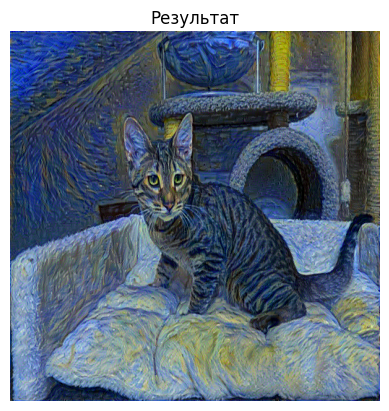

In [154]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используется устройство: {device}")

# Трансформации для загрузки картинок (включая нормализацию под VGG)
loader = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def image_loader(path):
    image = Image.open(path).convert('RGB')
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

# Функция для «денормализации» и показа изображения
def imshow(tensor, title=None):
    unloader = transforms.ToPILImage()
    image = tensor.cpu().clone().squeeze(0)
    image = unloader(image)
    if title:
        plt.title(title)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

def gram_matrix(input):
    b, c, h, w = input.size()
    features = input.view(b, c, h * w)
    G = torch.bmm(features, features.transpose(1, 2))
    return G.div(c * h * w)

class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        # «Отвязываем» целевой тензор от графа вычислений
        self.target = target.detach()
        self.loss = 0

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()
        self.loss = 0

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input

# Функция, собирающая модель и слои лоссов
def get_style_model_and_losses(cnn, style_img, content_img):
    # Здесь мы указываем имена слоёв, с которых будем снимать style/content
    # Важно: conv_21 обычно соответствует "conv4_2", если считать, что i
    # прирастает при каждом Conv/ReLU/Pool (как сделано ниже).
    content_layers = ['conv_21']  
    style_layers = ['conv_0', 'conv_5', 'conv_10', 'conv_19', 'conv_28']
    
    # Делаем копию CNN, чтобы не менять оригинальную
    cnn = copy.deepcopy(cnn)
    
    content_losses = []
    style_losses = []
    model = nn.Sequential()
    
    i = 0  # Счётчик, который меняется для conv/relu/pool
    for layer in cnn.children():
        # Переименовываем слои по аналогии с PyTorch Tutorial
        if isinstance(layer, nn.Conv2d):
            name = f'conv_{i}'
        elif isinstance(layer, nn.ReLU):
            name = f'relu_{i}'
            # Переводим ReLU в не-inplace
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = f'pool_{i}'
            # Заменяем max pooling на avg pooling
            layer = nn.AvgPool2d(kernel_size=2, stride=2)
        else:
            # Если BN или что-то ещё — пропускаем (в обычной vgg19 BN нет)
            continue
        
        model.add_module(name, layer)

        # Если слой в списке content_layers — цепляем к нему ContentLoss
        if name in content_layers:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module(f"content_loss_{i}", content_loss)
            content_losses.append(content_loss)
        
        # Если слой в списке style_layers — цепляем StyleLoss
        if name in style_layers:
            target = model(style_img).detach()
            style_loss = StyleLoss(target)
            model.add_module(f"style_loss_{i}", style_loss)
            style_losses.append(style_loss)
        
        i += 1
    
    return model, style_losses, content_losses

def run_style_transfer(cnn, content_img, style_img, input_img,
                       num_steps=1500, style_weight=1e6, content_weight=1):
    # Составляем модель со всеми лоссами
    model, style_losses, content_losses = get_style_model_and_losses(
        cnn, style_img, content_img
    )
    
    # Оптимизируем пиксели в input_img
    optimizer = optim.Adam([input_img.requires_grad_()], lr=0.02)

    print("🔁 Style transfer начался...")
    for step in range(num_steps):
        optimizer.zero_grad()
        model(input_img)
        
        # Суммируем лоссы
        style_loss_value = sum([sl.loss for sl in style_losses])
        content_loss_value = sum([cl.loss for cl in content_losses])
        
        total_loss = style_weight * style_loss_value + content_weight * content_loss_value
        total_loss.backward()
        optimizer.step()
        
        # Каждые 50 шагов печатаем лоссы с нормальной точностью
        if step % 50 == 0:
            print(f"Шаг {step}, Style Loss: {style_loss_value.item():.6f}, "
                  f"Content Loss: {content_loss_value.item():.6f}")

    return input_img

# Загрузка картинок
content_img = image_loader("cat.jpg")
style_img = image_loader("style.jpg")

# ИНИЦИАЛИЗАЦИЯ ВХОДА ШУМОМ
# (Чтобы лосс не был нулевым с самого начала)
input_img = content_img

# Загружаем и переводим в eval() VGG19
cnn = models.vgg19(pretrained=True).features.to(device).eval()

# Запуск
output = run_style_transfer(cnn, content_img, style_img, input_img)

# Денормализация для вывода
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1).to(device)
    return tensor * std + mean

# Превращаем тензор в диапазон [0,1] и показываем
result = denormalize(output.clone().squeeze(0)).clamp(0, 1)
imshow(result, title="Результат")